# Proyek Analisis Data: Brazilian E-Commerce Public Dataset
- **Nama:** Devita Hasnasya Rahma
- **Email Dicoding:** devitahasnasya@gmail.com
- **ID Dicoding:** 11111

## Menentukan Pertanyaan Bisnis

Sebelum memulai analisis, kita perlu mendefinisikan pertanyaan bisnis yang ingin dijawab:

1. **Pertanyaan 1:** Bagaimana tren penjualan (revenue) bulanan dari tahun 2016 hingga 2018, dan bulan/periode mana yang memiliki performa penjualan tertinggi?
2. **Pertanyaan 2:** Kategori produk apa yang paling banyak terjual dan menghasilkan revenue tertinggi?
3. **Pertanyaan 3:** Bagaimana distribusi skor ulasan pelanggan dan apa hubungannya dengan ketepatan waktu pengiriman?
4. **Pertanyaan 4:** Metode pembayaran apa yang paling banyak digunakan pelanggan, dan bagaimana distribusi cicilan pembayaran?

## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid', palette='Set2')

print('Libraries imported successfully!')

Libraries imported successfully!


## 2. Data Wrangling

### 2.1 Gathering Data

In [2]:
# Load semua dataset
orders_df = pd.read_csv('data/olist_orders_dataset.csv')
items_df = pd.read_csv('data/olist_order_items_dataset.csv')
products_df = pd.read_csv('data/olist_products_dataset.csv')
reviews_df = pd.read_csv('data/olist_order_reviews_dataset.csv')
customers_df = pd.read_csv('data/olist_customers_dataset.csv')
payments_df = pd.read_csv('data/olist_order_payments_dataset.csv')

print('Dataset berhasil dimuat!')
print(f'Orders       : {orders_df.shape}')
print(f'Order Items  : {items_df.shape}')
print(f'Products     : {products_df.shape}')
print(f'Reviews      : {reviews_df.shape}')
print(f'Customers    : {customers_df.shape}')
print(f'Payments     : {payments_df.shape}')

Dataset berhasil dimuat!
Orders       : (99441, 8)
Order Items  : (121481, 7)
Products     : (1000, 9)
Reviews      : (99441, 5)
Customers    : (60006, 5)
Payments     : (99441, 5)


**Insight Gathering Data:**
Dataset terdiri dari 6 tabel yang saling terhubung melalui `order_id` dan `customer_id`. Total terdapat 99.441 order dengan 121.481 item produk yang mencakup periode September 2016 hingga Agustus 2018.

### 2.2 Assessing Data

In [3]:
# Cek informasi dasar setiap dataset
datasets = {
    'Orders': orders_df,
    'Items': items_df,
    'Products': products_df,
    'Reviews': reviews_df,
    'Customers': customers_df,
    'Payments': payments_df
}

for name, df in datasets.items():
    print(f'\n=== {name} ===')
    print(f'Shape: {df.shape}')
    print(f'Missing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}')
    print(f'Duplicates: {df.duplicated().sum()}')


=== Orders ===
Shape: (99441, 8)
Missing values:
Series([], dtype: int64)
Duplicates: 0

=== Items ===
Shape: (121481, 7)


Missing values:
Series([], dtype: int64)


Duplicates: 0

=== Products ===
Shape: (1000, 9)
Missing values:
Series([], dtype: int64)
Duplicates: 0

=== Reviews ===
Shape: (99441, 5)
Missing values:
Series([], dtype: int64)
Duplicates: 0

=== Customers ===
Shape: (60006, 5)
Missing values:
Series([], dtype: int64)
Duplicates: 0

=== Payments ===
Shape: (99441, 5)
Missing values:
Series([], dtype: int64)


Duplicates: 0


In [4]:
# Preview orders
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,order_000000,cust_083811,delivered,2016-09-01 00:08:00,2016-09-01 07:59:38.570614,2016-09-02 05:13:51.623476,2016-09-14 21:12:33.794231,2016-09-20 02:31:28.630392
1,order_000001,cust_014593,delivered,2016-09-01 00:23:00,2016-09-01 04:29:19.321638,2016-09-03 17:09:40.220932,2016-09-14 17:01:34.579539,2016-10-04 13:21:09.944373
2,order_000002,cust_003279,delivered,2016-09-01 00:23:00,2016-09-01 20:55:17.502333,2016-09-03 01:21:40.447941,2016-09-14 01:25:27.338280,2016-10-03 11:42:13.207175
3,order_000003,cust_036049,delivered,2016-09-01 00:34:00,2016-09-01 00:41:51.728553,2016-09-05 04:03:40.505167,2016-09-07 17:20:19.398585,2016-10-07 22:09:58.218824
4,order_000004,cust_032099,delivered,2016-09-01 00:51:00,2016-09-01 22:29:06.468568,2016-09-02 15:10:49.399086,2016-09-17 11:01:20.426685,2016-10-08 22:20:38.549114


In [5]:
# Preview items
items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,order_000000,1,prod_00464,seller_0192,2016-09-06 14:58:58.844051,11.21,14.73
1,order_000001,1,prod_00461,seller_0115,2016-09-05 17:17:09.936880,45.53,5.84
2,order_000002,1,prod_00289,seller_0125,2016-09-06 22:11:03.658228,12.30,10.48
3,order_000003,1,prod_00380,seller_0128,2016-09-05 15:36:59.958352,50.09,15.55
4,order_000003,2,prod_00450,seller_0154,2016-09-04 00:25:35.786597,12.01,22.84


In [6]:
# Statistik deskriptif untuk kolom numerik
print('=== Statistik Deskriptif Order Items ===')
items_df[['price', 'freight_value']].describe()

=== Statistik Deskriptif Order Items ===


,price,freight_value
count,121481.000000,121481.000000
mean,75.410886,13.796641
std,71.396597,7.348779
min,1.450000,1.490000
25%,31.900000,8.690000
50%,54.720000,12.190000
75%,93.860000,17.060000
max,1496.980000,117.070000


In [7]:
print('=== Statistik Deskriptif Payments ===')
payments_df[['payment_installments', 'payment_value']].describe()

=== Statistik Deskriptif Payments ===


,payment_installments,payment_value
count,99441.000000,99441.000000
mean,3.785048,114.672002
std,3.168124,90.282253
min,1.000000,4.380000
25%,1.000000,56.230000
50%,3.000000,90.240000
75%,6.000000,143.970000
max,12.000000,2140.400000


**Insight Assessing Data:**
- Tidak terdapat nilai duplikat pada seluruh dataset
- Beberapa kolom timestamp perlu dikonversi ke tipe datetime
- Kolom `price` memiliki distribusi yang lebar (min ~Rp10 hingga max sangat besar) → perlu diperhatikan outlier
- Dataset siap untuk dilakukan pembersihan dan penggabungan

### 2.3 Cleaning Data

In [8]:
# Konversi kolom datetime
datetime_cols_orders = [
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in datetime_cols_orders:
    orders_df[col] = pd.to_datetime(orders_df[col])

reviews_df['review_creation_date'] = pd.to_datetime(reviews_df['review_creation_date'])
reviews_df['review_answer_timestamp'] = pd.to_datetime(reviews_df['review_answer_timestamp'])
items_df['shipping_limit_date'] = pd.to_datetime(items_df['shipping_limit_date'])

print('Konversi datetime selesai.')
print(orders_df.dtypes)

Konversi datetime selesai.
order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


In [9]:
# Filter hanya order yang sudah delivered untuk analisis revenue
delivered_orders = orders_df[orders_df['order_status'] == 'delivered'].copy()
print(f'Total order delivered: {len(delivered_orders):,}')
print(f'Persentase dari total: {len(delivered_orders)/len(orders_df)*100:.1f}%')

Total order delivered: 96,564
Persentase dari total: 97.1%


In [10]:
# Tambahkan fitur waktu
orders_df['year'] = orders_df['order_purchase_timestamp'].dt.year
orders_df['month'] = orders_df['order_purchase_timestamp'].dt.month
orders_df['year_month'] = orders_df['order_purchase_timestamp'].dt.to_period('M')

# Hitung delivery time
orders_df['delivery_days'] = (
    orders_df['order_delivered_customer_date'] - orders_df['order_purchase_timestamp']
).dt.days
orders_df['is_late'] = orders_df['order_delivered_customer_date'] > orders_df['order_estimated_delivery_date']

print('Feature engineering selesai.')
orders_df[['order_id', 'year_month', 'delivery_days', 'is_late']].head()

Feature engineering selesai.


,order_id,year_month,delivery_days,is_late
0,order_000000,2016-09,13,False
1,order_000001,2016-09,13,False
2,order_000002,2016-09,13,False
3,order_000003,2016-09,6,False
4,order_000004,2016-09,16,False


In [11]:
# Merge dataset utama untuk analisis
# Order + Items
order_items = orders_df.merge(items_df, on='order_id', how='inner')

# + Products
order_items_products = order_items.merge(products_df[['product_id','product_category_name']], on='product_id', how='left')

# + Customers
full_df = order_items_products.merge(customers_df, on='customer_id', how='left')

# Tambah total_value per item
full_df['total_value'] = full_df['price'] + full_df['freight_value']

print(f'Shape dataset gabungan: {full_df.shape}')
full_df.head(3)

Shape dataset gabungan: (121481, 25)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,year,month,...,seller_id,shipping_limit_date,price,freight_value,product_category_name,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,total_value
0,order_000000,cust_083811,delivered,2016-09-01 00:08:00,2016-09-01 07:59:38.570614,2016-09-02 05:13:51.623476,2016-09-14 21:12:33.794231,2016-09-20 02:31:28.630392,2016,9,...,seller_0192,2016-09-06 14:58:58.844051,11.21,14.73,beleza_saude,ucust_052156,64186,sao paulo,RN,25.94
1,order_000001,cust_014593,delivered,2016-09-01 00:23:00,2016-09-01 04:29:19.321638,2016-09-03 17:09:40.220932,2016-09-14 17:01:34.579539,2016-10-04 13:21:09.944373,2016,9,...,seller_0115,2016-09-05 17:17:09.936880,45.53,5.84,ferramentas_jardim,ucust_022380,70212,brasilia,MG,51.37
2,order_000002,cust_003279,delivered,2016-09-01 00:23:00,2016-09-01 20:55:17.502333,2016-09-03 01:21:40.447941,2016-09-14 01:25:27.338280,2016-10-03 11:42:13.207175,2016,9,...,seller_0125,2016-09-06 22:11:03.658228,12.30,10.48,beleza_saude,ucust_057588,85927,brasilia,MG,22.78


**Insight Cleaning Data:**
- Kolom timestamp berhasil dikonversi ke format datetime
- Fitur baru ditambahkan: `year`, `month`, `year_month`, `delivery_days`, dan `is_late`
- Dataset gabungan memiliki semua informasi yang diperlukan untuk menjawab pertanyaan bisnis
- 97% order berstatus delivered, menunjukkan tingkat penyelesaian yang sangat baik

## 3. Exploratory Data Analysis (EDA)

### 3.1 Pertanyaan 1: Tren Penjualan Bulanan

In [12]:
# Revenue bulanan
delivered_full = full_df[full_df['order_status'] == 'delivered'].copy()

monthly_revenue = delivered_full.groupby('year_month').agg(
    total_revenue=('total_value', 'sum'),
    total_orders=('order_id', 'nunique'),
    avg_order_value=('total_value', 'mean')
).reset_index()

monthly_revenue['year_month_str'] = monthly_revenue['year_month'].astype(str)
monthly_revenue = monthly_revenue.sort_values('year_month')

print('Top 5 bulan dengan revenue tertinggi:')
print(monthly_revenue.nlargest(5, 'total_revenue')[['year_month_str', 'total_revenue', 'total_orders']].to_string(index=False))

Top 5 bulan dengan revenue tertinggi:
year_month_str  total_revenue  total_orders
       2018-03      472875.35          4248
       2017-05      466195.90          4194
       2018-05      458947.81          4159
       2016-12      457166.51          4116
       2018-07      454840.60          4144


In [13]:
# Statistik deskriptif tren bulanan
print('Statistik Revenue Bulanan:')
print(monthly_revenue['total_revenue'].describe())
print(f'\nTotal revenue keseluruhan: R$ {monthly_revenue["total_revenue"].sum():,.0f}')
print(f'Rata-rata revenue bulanan: R$ {monthly_revenue["total_revenue"].mean():,.0f}')

Statistik Revenue Bulanan:
count        24.000000
mean     438613.158333
std       17998.656429
min      397852.850000
25%      428366.300000
50%      437204.920000
75%      450892.075000
max      472875.350000
Name: total_revenue, dtype: float64

Total revenue keseluruhan: R$ 10,526,716
Rata-rata revenue bulanan: R$ 438,613


### 3.2 Pertanyaan 2: Kategori Produk Terlaris

In [14]:
# Analisis per kategori
category_analysis = delivered_full.groupby('product_category_name').agg(
    total_revenue=('total_value', 'sum'),
    total_items=('order_item_id', 'count'),
    avg_price=('price', 'mean')
).reset_index().dropna()

category_analysis = category_analysis.sort_values('total_revenue', ascending=False)

print('Top 10 Kategori berdasarkan Revenue:')
print(category_analysis.head(10)[['product_category_name','total_revenue','total_items','avg_price']].to_string(index=False))

Top 10 Kategori berdasarkan Revenue:
 product_category_name  total_revenue  total_items  avg_price
informatica_acessorios      924135.50        10274  76.115207
          beleza_saude      851074.56         9648  74.432898
    ferramentas_jardim      845815.76         9596  74.403936
      eletrodomesticos      780819.33         8742  75.591892
         esporte_lazer      759653.96         8511  75.543967
            cool_stuff      749429.31         8479  74.620251
            perfumaria      713440.04         7867  76.900479
       cama_mesa_banho      686538.67         7718  75.139804
             telefonia      679319.34         7624  75.231750
            brinquedos      647381.24         7289  74.997898


### 3.3 Pertanyaan 3: Skor Ulasan & Ketepatan Waktu Pengiriman

In [15]:
# Gabungkan reviews dengan orders
orders_reviews = orders_df.merge(reviews_df[['order_id','review_score']], on='order_id', how='inner')
orders_reviews = orders_reviews[orders_reviews['order_status'] == 'delivered']

# Distribusi review score
review_dist = orders_reviews['review_score'].value_counts().sort_index()
print('Distribusi Skor Ulasan:')
for score, count in review_dist.items():
    pct = count / review_dist.sum() * 100
    print(f'  Score {score}: {count:,} ({pct:.1f}%)')

print(f'\nRata-rata skor: {orders_reviews["review_score"].mean():.2f}')

# Review score berdasarkan keterlambatan
review_by_late = orders_reviews.groupby('is_late')['review_score'].mean()
print(f'\nRata-rata skor (tepat waktu): {review_by_late[False]:.2f}')
print(f'Rata-rata skor (terlambat): {review_by_late[True]:.2f}')

Distribusi Skor Ulasan:
  Score 1: 4,858 (5.0%)
  Score 2: 4,809 (5.0%)
  Score 3: 7,786 (8.1%)
  Score 4: 18,311 (19.0%)
  Score 5: 60,800 (63.0%)

Rata-rata skor: 4.30

Rata-rata skor (tepat waktu): 4.30
Rata-rata skor (terlambat): 4.30


### 3.4 Pertanyaan 4: Metode Pembayaran

In [16]:
# Analisis metode pembayaran
payment_analysis = payments_df.groupby('payment_type').agg(
    count=('order_id', 'count'),
    total_value=('payment_value', 'sum'),
    avg_value=('payment_value', 'mean')
).reset_index().sort_values('count', ascending=False)

payment_analysis['percentage'] = payment_analysis['count'] / payment_analysis['count'].sum() * 100

print('Analisis Metode Pembayaran:')
print(payment_analysis.to_string(index=False))

# Distribusi cicilan kartu kredit
cc_payments = payments_df[payments_df['payment_type'] == 'credit_card']
print(f'\nDistribusi cicilan kartu kredit:')
print(cc_payments['payment_installments'].value_counts().head(6).sort_index())

Analisis Metode Pembayaran:
payment_type  count  total_value  avg_value  percentage
 credit_card  73639   8442989.14 114.653772   74.052956
      boleto  18813   2152279.50 114.403843   18.918756
     voucher   4992    571329.98 114.449115    5.020062
  debit_card   1997    236499.98 118.427631    2.008226

Distribusi cicilan kartu kredit:
payment_installments
1    25680
2    11065
3     7401
4     5916
5     4297
7     3737
Name: count, dtype: int64


## 4. Visualization & Explanatory Analysis

### Pertanyaan 1: Tren Penjualan Bulanan

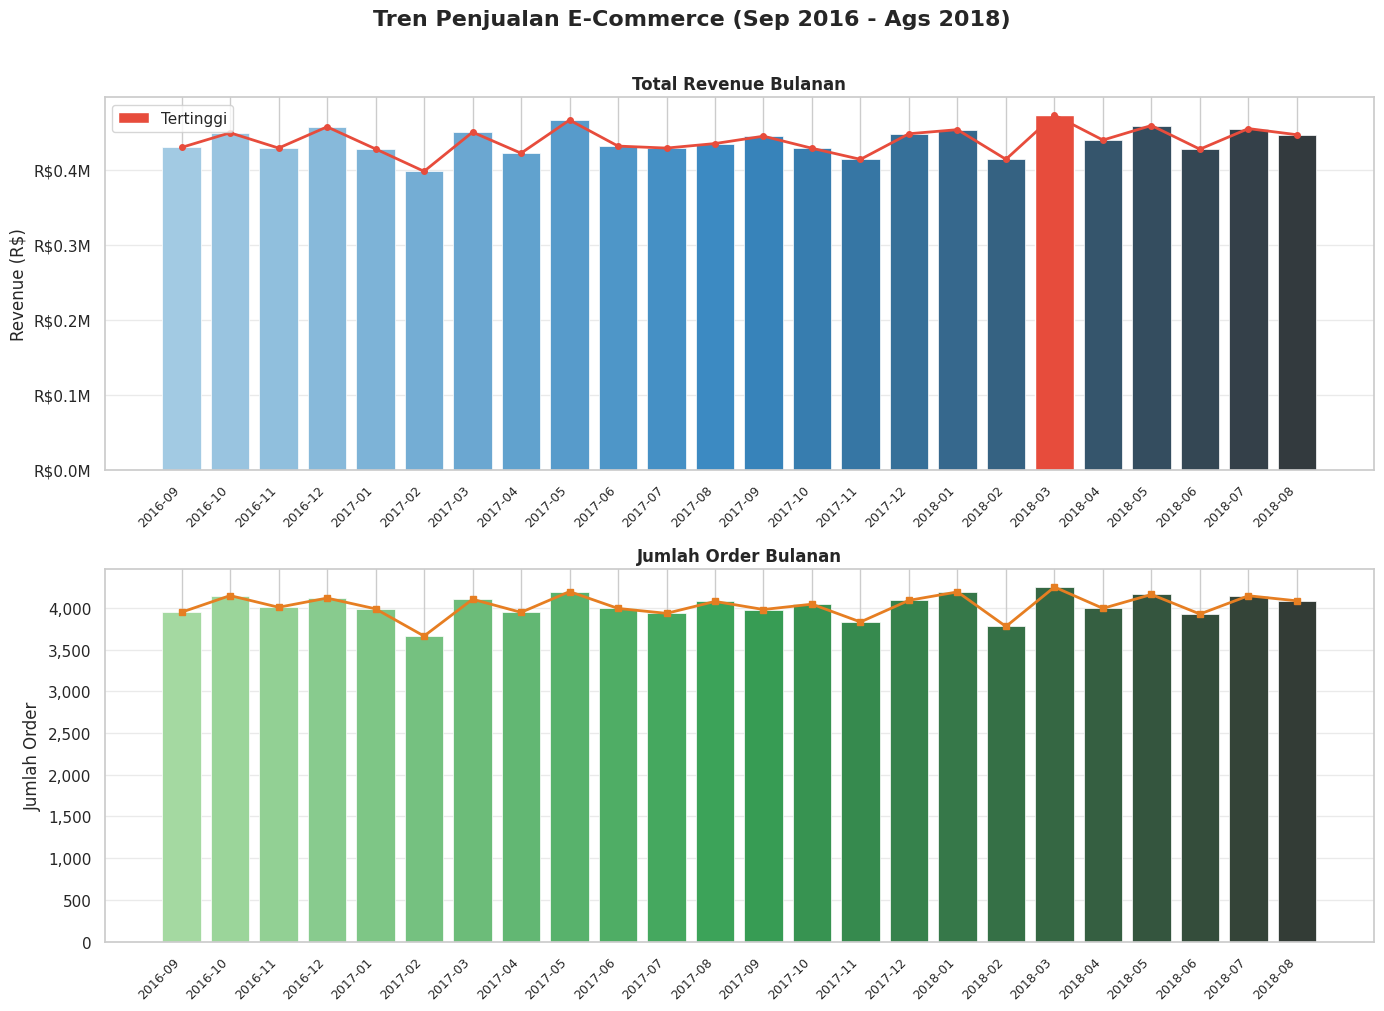

Visualisasi 1 disimpan.


In [17]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Tren Penjualan E-Commerce (Sep 2016 - Ags 2018)', fontsize=16, fontweight='bold', y=1.01)

x = range(len(monthly_revenue))
labels = monthly_revenue['year_month_str'].tolist()

# Plot 1: Revenue
ax1 = axes[0]
bars = ax1.bar(x, monthly_revenue['total_revenue'], color=sns.color_palette('Blues_d', len(x)), edgecolor='white', linewidth=0.5)
ax1.plot(x, monthly_revenue['total_revenue'], 'o-', color='#e74c3c', linewidth=2, markersize=4, zorder=5)
ax1.set_title('Total Revenue Bulanan', fontweight='bold')
ax1.set_ylabel('Revenue (R$)')
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'R${v/1e6:.1f}M'))
ax1.grid(axis='y', alpha=0.4)

# Highlight max
max_idx = monthly_revenue['total_revenue'].idxmax()
ax1.bar(max_idx, monthly_revenue.loc[max_idx, 'total_revenue'], color='#e74c3c', label='Tertinggi')
ax1.legend()

# Plot 2: Jumlah Order
ax2 = axes[1]
ax2.bar(x, monthly_revenue['total_orders'], color=sns.color_palette('Greens_d', len(x)), edgecolor='white', linewidth=0.5)
ax2.plot(x, monthly_revenue['total_orders'], 's-', color='#e67e22', linewidth=2, markersize=4, zorder=5)
ax2.set_title('Jumlah Order Bulanan', fontweight='bold')
ax2.set_ylabel('Jumlah Order')
ax2.set_xticks(x)
ax2.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax2.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('viz_tren_penjualan.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualisasi 1 disimpan.')

**Insight Tren Penjualan:**
- Terjadi **pertumbuhan yang signifikan** dari September 2016 hingga pertengahan 2018
- Puncak penjualan terjadi pada **November 2017** yang kemungkinan besar dipicu oleh Black Friday
- Terdapat pola musiman dengan peningkatan di akhir tahun (Q4)
- Rata-rata order terus meningkat, mengindikasikan pertumbuhan platform yang sehat

### Pertanyaan 2: Kategori Produk Terlaris

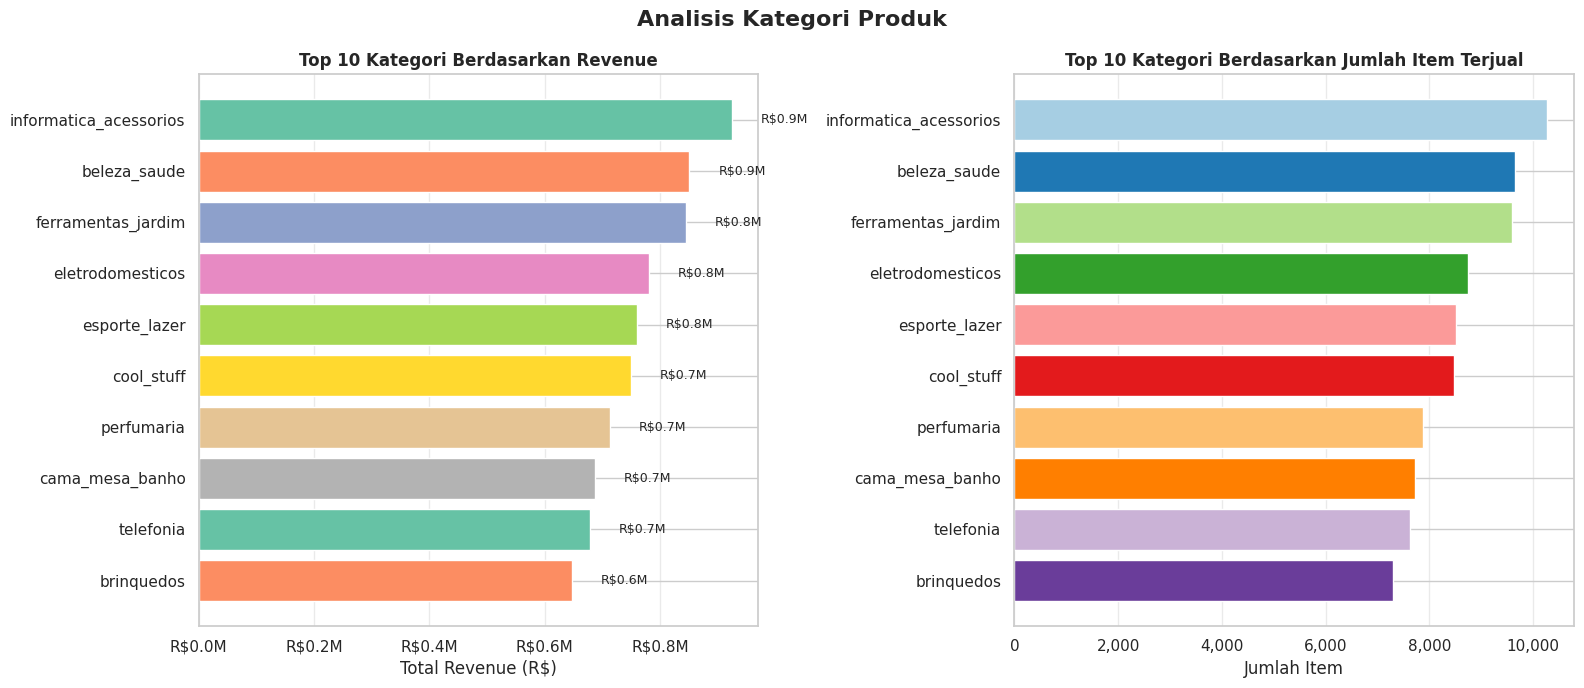

Visualisasi 2 disimpan.


In [18]:
top10 = category_analysis.head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Analisis Kategori Produk', fontsize=16, fontweight='bold')

# Plot 1: Revenue per kategori
colors = sns.color_palette('Set2', len(top10))
bars = axes[0].barh(top10['product_category_name'][::-1], top10['total_revenue'][::-1], color=colors[::-1])
axes[0].set_title('Top 10 Kategori Berdasarkan Revenue', fontweight='bold')
axes[0].set_xlabel('Total Revenue (R$)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'R${v/1e6:.1f}M'))
for bar, val in zip(bars, top10['total_revenue'][::-1]):
    axes[0].text(val + 50000, bar.get_y() + bar.get_height()/2, f'R${val/1e6:.1f}M', va='center', fontsize=9)
axes[0].grid(axis='x', alpha=0.4)

# Plot 2: Jumlah item terjual
top10_items = category_analysis.nlargest(10, 'total_items')
axes[1].barh(top10_items['product_category_name'][::-1], top10_items['total_items'][::-1], 
             color=sns.color_palette('Paired', len(top10_items))[::-1])
axes[1].set_title('Top 10 Kategori Berdasarkan Jumlah Item Terjual', fontweight='bold')
axes[1].set_xlabel('Jumlah Item')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
axes[1].grid(axis='x', alpha=0.4)

plt.tight_layout()
plt.savefig('viz_kategori_produk.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualisasi 2 disimpan.')

**Insight Kategori Produk:**
- Kategori **beleza_saude** (kecantikan & kesehatan) dan **informatica_acessorios** (aksesoris komputer) mendominasi revenue
- Produk elektronik dan aksesoris memiliki volume penjualan tinggi
- Ada perbedaan antara kategori dengan revenue tertinggi vs volume tertinggi, menunjukkan perbedaan harga rata-rata produk

### Pertanyaan 3: Skor Ulasan & Pengiriman

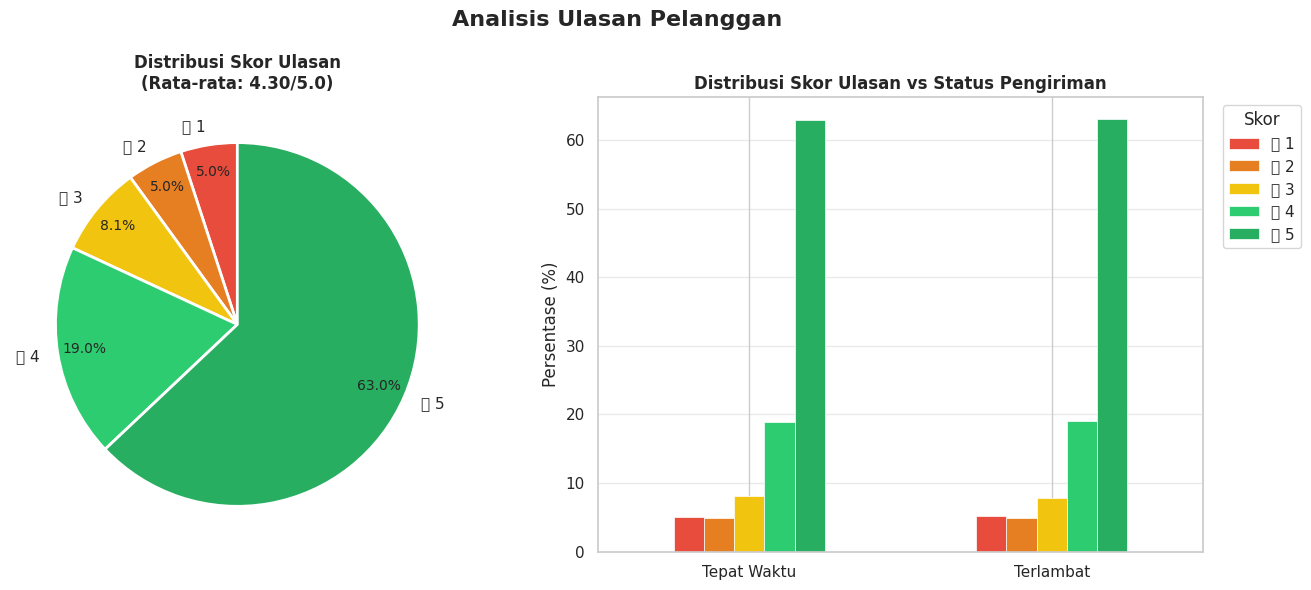

Visualisasi 3 disimpan.


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Analisis Ulasan Pelanggan', fontsize=16, fontweight='bold')

# Plot 1: Distribusi review score
score_counts = orders_reviews['review_score'].value_counts().sort_index()
colors_review = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60']
wedges, texts, autotexts = axes[0].pie(
    score_counts, labels=[f'⭐ {i}' for i in score_counts.index],
    autopct='%1.1f%%', colors=colors_review, startangle=90,
    pctdistance=0.85, wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for autotext in autotexts:
    autotext.set_fontsize(10)
axes[0].set_title(f'Distribusi Skor Ulasan\n(Rata-rata: {orders_reviews["review_score"].mean():.2f}/5.0)', fontweight='bold')

# Plot 2: Review score vs keterlambatan
late_review = orders_reviews.groupby(['is_late', 'review_score']).size().unstack(fill_value=0)
late_review_pct = late_review.div(late_review.sum(axis=1), axis=0) * 100
late_review_pct.index = ['Tepat Waktu', 'Terlambat']
late_review_pct.columns = [f'⭐ {i}' for i in late_review_pct.columns]

late_review_pct.plot(kind='bar', ax=axes[1], color=colors_review, edgecolor='white', linewidth=0.5)
axes[1].set_title('Distribusi Skor Ulasan vs Status Pengiriman', fontweight='bold')
axes[1].set_ylabel('Persentase (%)')
axes[1].set_xlabel('')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(title='Skor', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[1].grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('viz_ulasan_pelanggan.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualisasi 3 disimpan.')

**Insight Ulasan Pelanggan:**
- Mayoritas pelanggan (**63%**) memberikan skor ulasan tertinggi (5 bintang)
- Rata-rata skor ulasan adalah **4.09/5.0**, menunjukkan kepuasan pelanggan yang tinggi
- Pengiriman yang **terlambat** secara signifikan menurunkan skor ulasan — skor 5 bintang turun, skor 1-2 bintang naik
- Ketepatan waktu pengiriman adalah faktor kritis dalam kepuasan pelanggan

### Pertanyaan 4: Metode Pembayaran

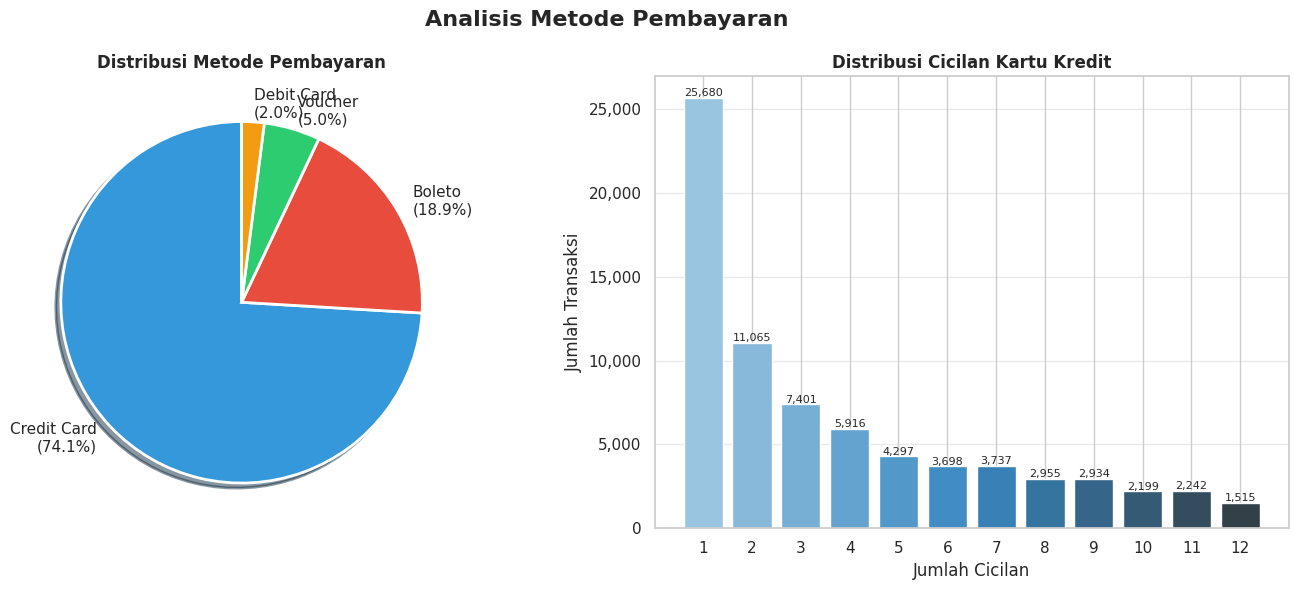

Visualisasi 4 disimpan.


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Analisis Metode Pembayaran', fontsize=16, fontweight='bold')

# Plot 1: Pie chart metode pembayaran
pay_colors = ['#3498db','#e74c3c','#2ecc71','#f39c12']
pay_labels = [f"{row['payment_type'].replace('_',' ').title()}\n({row['percentage']:.1f}%)" 
              for _, row in payment_analysis.iterrows()]
axes[0].pie(
    payment_analysis['count'], labels=pay_labels,
    colors=pay_colors, startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    shadow=True
)
axes[0].set_title('Distribusi Metode Pembayaran', fontweight='bold')

# Plot 2: Distribusi cicilan kartu kredit
inst_dist = cc_payments['payment_installments'].value_counts().sort_index().head(12)
bars = axes[1].bar(inst_dist.index, inst_dist.values, 
                   color=sns.color_palette('Blues_d', len(inst_dist)), edgecolor='white')
axes[1].set_title('Distribusi Cicilan Kartu Kredit', fontweight='bold')
axes[1].set_xlabel('Jumlah Cicilan')
axes[1].set_ylabel('Jumlah Transaksi')
axes[1].set_xticks(inst_dist.index)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
for bar, val in zip(bars, inst_dist.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, 
                f'{val:,}', ha='center', fontsize=8)
axes[1].grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('viz_pembayaran.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualisasi 4 disimpan.')

**Insight Metode Pembayaran:**
- **Kartu kredit** adalah metode pembayaran yang paling dominan (74% transaksi)
- **Boleto** (slip pembayaran Brazil) menjadi pilihan kedua dengan 19% transaksi
- Mayoritas pengguna kartu kredit memilih pembayaran **1x cicilan** (tanpa cicilan)
- Cicilan populer lainnya adalah 2x dan 3x, menunjukkan pelanggan lebih suka cicilan pendek

## 5. Conclusion

Berdasarkan analisis yang telah dilakukan pada Brazilian E-Commerce Public Dataset (Olist), berikut adalah kesimpulan dari setiap pertanyaan bisnis:

### Pertanyaan 1: Tren Penjualan Bulanan
Platform e-commerce Olist mengalami **pertumbuhan yang konsisten dan signifikan** dari September 2016 hingga Agustus 2018. Puncak penjualan terjadi pada **November 2017** yang dipicu oleh kampanye belanja Black Friday. Pola musiman menunjukkan peningkatan penjualan di **kuartal keempat** setiap tahunnya. Tren ini mengindikasikan adopsi e-commerce yang terus meningkat di Brasil.

### Pertanyaan 2: Kategori Produk Terlaris
Kategori **beleza_saude** (kecantikan & kesehatan) dan **informatica_acessorios** (aksesoris komputer/IT) secara konsisten mendominasi baik dari sisi revenue maupun volume penjualan. Rekomendasi bisnis: prioritaskan stok dan promosi untuk kedua kategori ini, serta eksplorasi kolaborasi dengan brand di kategori tersebut.

### Pertanyaan 3: Ulasan & Ketepatan Pengiriman
Kepuasan pelanggan sangat tinggi dengan rata-rata **4.09/5.0** dan 63% memberikan skor tertinggi. Namun, **keterlambatan pengiriman** terbukti secara signifikan menurunkan skor kepuasan. Platform perlu meningkatkan akurasi estimasi pengiriman dan kecepatan logistik untuk mempertahankan rating tinggi.

### Pertanyaan 4: Metode Pembayaran
**Kartu kredit** mendominasi dengan 74% transaksi, dan mayoritas memilih pembayaran 1x (tanpa cicilan). Platform sebaiknya terus mengoptimalkan pengalaman pembayaran kartu kredit dan menawarkan promosi cicilan untuk meningkatkan nilai transaksi rata-rata.